# Determining how common large events are.

This notebook will identify how many days it takes to reach a certain amount of precipitation each year. 

We will try to answer the following questions: 
1) Is it many days? 
2) Only a few days?
3) Is it variable year-to-year?

We will use three datasets to do this: billy_barr_precip data, 2 local snotel sites (Butte and Schofield Pass), and PRISM. These 3 datasets will try to establish how much variability is involved across space and time. 

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

In [8]:
DATA_DIR = "/storage/dlhogan/precipitation-rodeo/data/processed/"
# import snotel data
sntl_df = pd.read_csv(f"{DATA_DIR}final/east_river_snotel_daily.csv", index_col=0, parse_dates=True)
sntl_df.index = pd.to_datetime(sntl_df.index.date)
# import billy barr data
bb_ds = xr.open_dataset(f"{DATA_DIR}/billy_barr/billy_barr_20011001-20251025_30min.nc")
# import PRISM data
# prism_ds


In [9]:
bb_valid_dates = slice("2016-10-01","2025-09-30")
bb_ds_filtered = bb_ds.sel(time=bb_valid_dates).where(bb_ds['precip']>=0)

flag_mask = (~bb_ds_filtered['precip_bad_flag'].astype(bool) | ~bb_ds_filtered['precip_missing_flag'].astype(bool))

bb_ds_filtered_daily = bb_ds_filtered.where(flag_mask, np.nan)['precip'].resample(time='1D').sum()
bb_precip_df = bb_ds_filtered_daily.to_dataframe()


In [10]:
bb_precip_df['WY'] = bb_precip_df.index.year.where(bb_precip_df.index.month<10, bb_precip_df.index.year+1)
sntl_df['WY'] = sntl_df.index.year.where(sntl_df.index.month<10, sntl_df.index.year+1)

In [11]:
site_filter = sntl_df['site']=='380:CO:SNTL'
swe_filter = site_filter & (sntl_df['SWE']==0)
# identify index (last day before) 12/31 where SWE is 0
swe_start = sntl_df[swe_filter].loc[sntl_df[swe_filter].index.month>9].reset_index().groupby('WY').last()['index']
# add 1 day to get first day of SWE accumulation
swe_start = swe_start + pd.Timedelta(days=7)

In [12]:
# last day before 12/31 where SWE is 0
butte_peak_swe_date = sntl_df[['SWE','WY']][sntl_df['site']=='380:CO:SNTL'].groupby('WY').idxmax()
schofield_peak_swe_date = sntl_df[['SWE','WY']][sntl_df['site']=='737:CO:SNTL'].groupby('WY').idxmax()  

## Filter to days with 0 in gauge when other gauge or pillow records precipitation

In [ ]:
butte_df = sntl_df[sntl_df['site']=='380:CO:SNTL']
schofield_df = sntl_df[sntl_df['site']=='737:CO:SNTL']

Index(['site', 'geometry', 'ACCUMULATED PRECIPITATION',
       'ACCUMULATED PRECIPITATION_units', 'PRECIPITATION',
       'PRECIPITATION_units', 'SWE', 'SWE_units', 'AVG AIR TEMP',
       'AVG AIR TEMP_units', 'datasource', 'WY'],
      dtype='object')

In [106]:
prcp_local = ((butte_df['PRECIPITATION'] == 0) & (schofield_df['PRECIPITATION'] > 0.5))
snow_no_prcp = (((butte_df['PRECIPITATION'] == 0) & (butte_df['SWE'].diff() > 0)) | prcp_local)
prcp_no_snow = ((butte_df['PRECIPITATION'] > 0.1) & (butte_df['SWE'].diff() == 0) & (butte_df['SWE'] > 0) & (butte_df['AVG AIR TEMP'] > 0))
# if the day after snow_sno_prcp is true, prco_no_snow is also true, change both to false
for idx in butte_df.index[1:]:
    if (snow_no_prcp.loc[idx - pd.Timedelta(days=1)]) & (prcp_no_snow.loc[idx]):
        snow_no_prcp.loc[idx - pd.Timedelta(days=1)] = False
        prcp_no_snow.loc[idx] = False
miscal = ((butte_df['PRECIPITATION'] - butte_df['SWE'].diff() > 0.1) & (butte_df['AVG AIR TEMP'] <= 0))

butte_df.loc[:, 'prcp_no_snow'] = prcp_no_snow
butte_df.loc[:, 'snow_no_prcp'] = snow_no_prcp
butte_df.loc[:, 'miscal'] = miscal

In [107]:
# sort by WY precipitation totals
wy_prcp_totals = butte_df.groupby('WY')['PRECIPITATION'].sum()

Text(0, 0.5, 'Total Bad or Missing Data (%)')

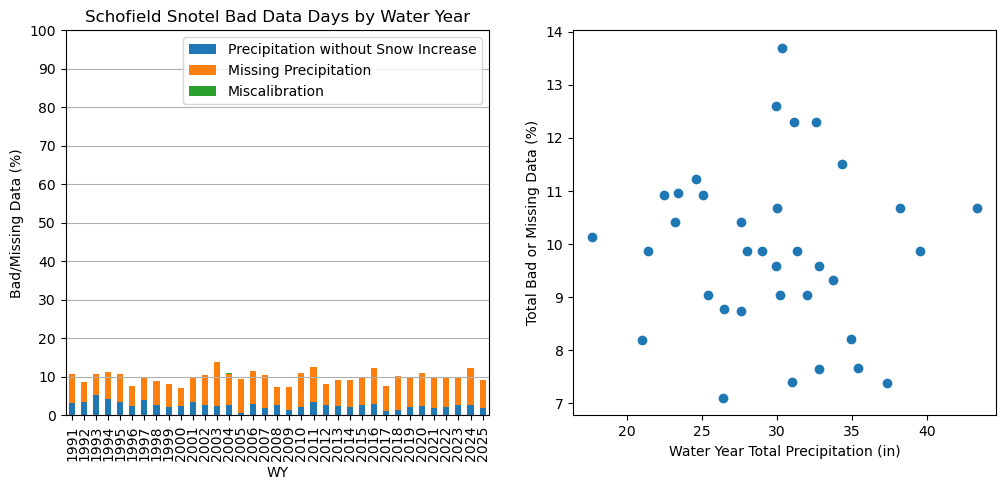

In [ ]:
# bar plot of bad data counts by water year stacked
bad_data_counts = butte_df[['prcp_no_snow','snow_no_prcp','miscal']].groupby(butte_df['WY']).sum() / butte_df[['prcp_no_snow','snow_no_prcp','miscal']].groupby(butte_df['WY']).count() * 100
# sort by WY precipitation totals
bad_data_counts = bad_data_counts.loc[wy_prcp_totals.index]

# rename columns
bad_data_counts.columns = ['Precipitation without snow increase', 'Missing Precipitation', 'Miscalibration']

fig, axs = plt.subplots(1,2, figsize=(12,5))
bad_data_counts.plot(kind='bar', stacked=True, ax=axs[0])
axs[0].set_ylabel('Bad/Missing Data (%)')
axs[0].set_title('Schofield Snotel Bad Data Days by Water Year')
axs[0].set_ylim(0,100)
axs[0].set_yticks(np.arange(0,110,10))
axs[0].grid(axis='y')

# sort by WY precipitation totals
wy_prcp_totals = butte_df.groupby('WY')['PRECIPITATION'].sum()
axs[1].plot(wy_prcp_totals.values, bad_data_counts.sum(axis=1).values, 'o')
axs[1].set_xlabel('Water Year Total Precipitation (in)')
axs[1].set_ylabel('Total Bad or Missing Data (%)')

In [ ]:
prcp_local = ((schofield_df['PRECIPITATION'] == 0) & (butte_df['PRECIPITATION'] > 0.5))
snow_no_prcp = (((schofield_df['PRECIPITATION'] == 0) & (schofield_df['SWE'].diff() > 0)) | prcp_local)
prcp_no_snow = ((schofield_df['PRECIPITATION'] > 0.1) & (schofield_df['SWE'].diff() == 0) & (schofield_df['SWE'] > 0) & (schofield_df['AVG AIR TEMP'] > 0))
# if the day after snow_sno_prcp is true, prco_no_snow is also true, change both to false
for idx in schofield_df.index[1:]:
    if (snow_no_prcp.loc[idx - pd.Timedelta(days=1)]) & (prcp_no_snow.loc[idx]):
        snow_no_prcp.loc[idx - pd.Timedelta(days=1)] = False
        prcp_no_snow.loc[idx] = False
miscal = ((schofield_df['PRECIPITATION'] - schofield_df['SWE'].diff() > 0.1) & (schofield_df['AVG AIR TEMP'] <= 0))


schofield_df.loc[:, 'prcp_no_snow'] = prcp_no_snow
schofield_df.loc[:, 'snow_no_prcp'] = snow_no_prcp
schofield_df.loc[:, 'miscal'] = miscal

/tmp/ipykernel_3615759/3838889769.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  schofield_df.loc[:, 'prcp_no_snow'] = prcp_no_snow
/tmp/ipykernel_3615759/3838889769.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  schofield_df.loc[:, 'snow_no_prcp'] = snow_no_prcp
/tmp/ipykernel_3615759/3838889769.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://

Text(0, 0.5, 'Total Bad or Missing Data (%)')

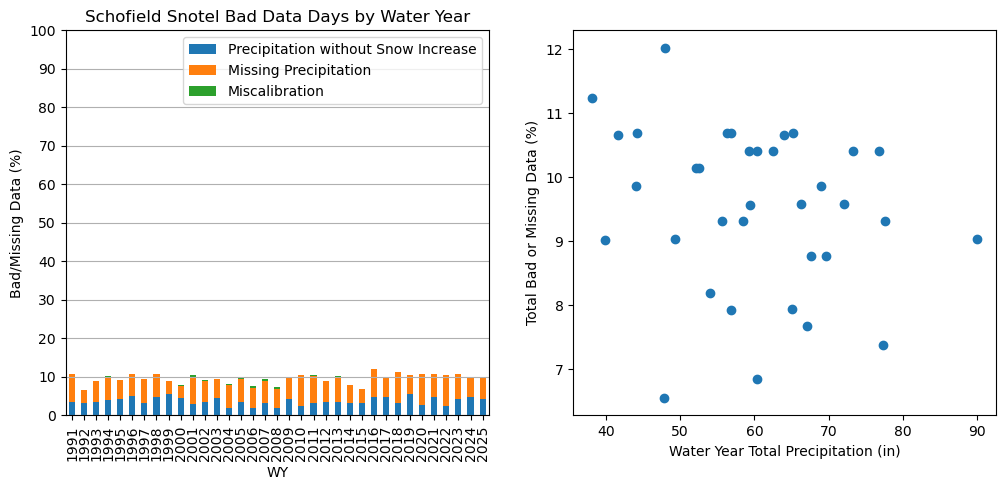

In [105]:
# bar plot of bad data counts by water year stacked
bad_data_counts = schofield_df[['prcp_no_snow','snow_no_prcp','miscal']].groupby(schofield_df['WY']).sum() / schofield_df[['prcp_no_snow','snow_no_prcp','miscal']].groupby(schofield_df['WY']).count() * 100
# sort by WY precipitation totals
bad_data_counts = bad_data_counts.loc[wy_prcp_totals.index]

# rename columns
bad_data_counts.columns = ['Precipitation without Snow Increase', 'Missing Precipitation', 'Miscalibration']

fig, axs = plt.subplots(1,2, figsize=(12,5))
bad_data_counts.plot(kind='bar', stacked=True, ax=axs[0])
axs[0].set_ylabel('Bad/Missing Data (%)')
axs[0].set_title('Schofield Snotel Bad Data Days by Water Year')
axs[0].set_ylim(0,100)
axs[0].set_yticks(np.arange(0,110,10))
axs[0].grid(axis='y')

# sort by WY precipitation totals
wy_prcp_totals = schofield_df.groupby('WY')['PRECIPITATION'].sum()
axs[1].plot(wy_prcp_totals.values, bad_data_counts.sum(axis=1).values, 'o')
axs[1].set_xlabel('Water Year Total Precipitation (in)')
axs[1].set_ylabel('Total Bad or Missing Data (%)')

In [109]:
def date_to_dowy(date):
    if date.month >=10:
        doy = (date - pd.Timestamp(year=date.year, month=10, day=1)).days + 1
    else:
        doy = (date - pd.Timestamp(year=date.year-1, month=10, day=1)).days
    return doy

date = pd.Timestamp('2020-09-29')
dowy = date_to_dowy(date)

In [124]:
snow_season = pd.DataFrame({
    'swe_start': swe_start,
    'butte_peak_swe_date': butte_peak_swe_date['SWE'],},
    index=swe_start.index
)
sntl_df_wy = sntl_df[site_filter].reset_index().set_index('WY')

season_dfs = []
for wy in sntl_df_wy.index.unique():
    start_date = snow_season.loc[wy,'swe_start']
    peak_date = snow_season.loc[wy,'butte_peak_swe_date']
    season_df = sntl_df_wy.loc[wy]
    season_df_filtered = season_df[(season_df['index']>=start_date) & (season_df['index']<=peak_date)]
    season_dfs.append(season_df_filtered)
season_snow_df = pd.concat(season_dfs)
season_snow_df = season_snow_df.reset_index().set_index('index')
# add day of water year
season_snow_df['DOWY'] = season_snow_df.index.to_series().apply(date_to_dowy)
# subtract accumulated precip by the first value
season_snow_df['ACCUMULATED PRECIPITATION'] = season_snow_df['PRECIPITATION'].cumsum() - season_snow_df['PRECIPITATION'].cumsum().groupby(season_snow_df['WY']).transform('first')


Text(0.5, 1.0, '2018 Snow Season at Butte Snotel - Precipitation vs SWE')

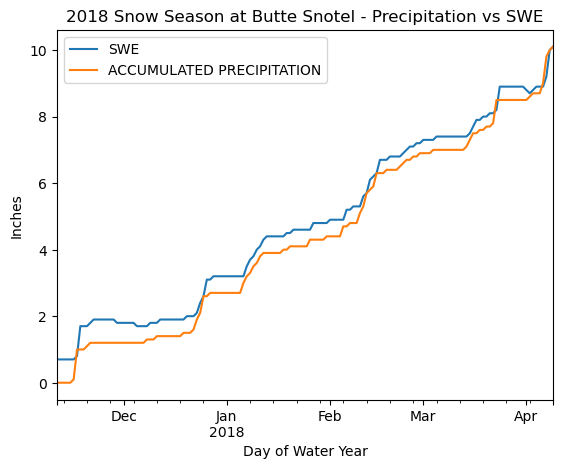

In [133]:
WY = 2018
season_snow_df[season_snow_df['WY']==WY].plot(y=['SWE','ACCUMULATED PRECIPITATION'])

plt.xlabel('Day of Water Year')
plt.ylabel('Inches')
plt.title(f'{WY} Snow Season at Butte Snotel - Precipitation vs SWE')

(0.8, 1.5)

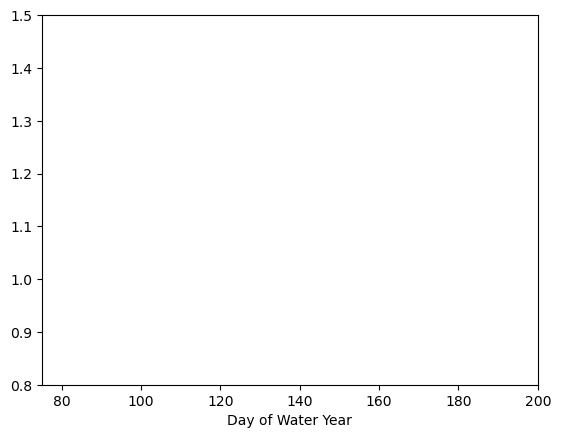

In [114]:
df_diff = season_snow_df[['SWE','ACCUMULATED PRECIPITATION']].diff()
# remove negative values
df_diff = df_diff[(df_diff['SWE']>=0) | (df_diff['ACCUMULATED PRECIPITATION']>=0)]

# add dowy
df_diff['DOWY'] = df_diff.index.to_series().apply(date_to_dowy)
# add water year
df_diff['WY'] = df_diff.index.year.where(df_diff.index.month<10, df_diff.index.year+1)

for wy in df_diff['WY'].unique():
    df_wy = df_diff[df_diff['WY']==wy]
    if wy in [2021, 2002, 2012,2018]:
        lw=3
        color='red'
    elif wy in [1993, 1995, 2005, 1997]:
        lw=3
        color='blue'
    else:
        lw=1
        color='gray'
    
    # plt.plot(df_wy['DOWY'], df_wy['SWE'].cumsum()/df_wy['ACCUMULATED PRECIPITATION'].cumsum(), 
    #          label=f'WY{wy}',
    #          linewidth=lw, color=color, alpha=0.7)
# add mean
df_dowy_mean = df_diff.groupby('DOWY').mean()
plt.plot(df_dowy_mean.index, df_dowy_mean['SWE'].cumsum(), color='k', linewidth=3, label='Mean')
# plt.axhline(1, color='red', linestyle='--', lw=4)
plt.xlabel('Day of Water Year')
# plt.ylabel('Cumulative SWE / Cumulative Precipitation')
plt.xlim(75,200)
plt.ylim(0.8,1.5)

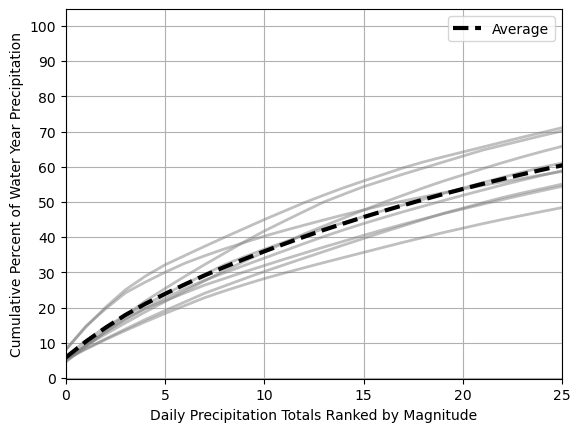

In [11]:
fig, ax = plt.subplots()

norm_list = []
for wy in bb_precip_df['WY'].unique():
    df = bb_precip_df[bb_precip_df['WY']==wy].sort_values('precip', ascending=False)['precip']
    days_with_precip = (df > 1).sum()
    # normalize by total precip
    df_norm = df/df.sum() * 100
    df_norm.reset_index(drop=True, inplace=True)
    df_norm.name = wy
    norm_list.append(df_norm)

    df_norm.cumsum().plot(ax=ax, lw=2, alpha=0.5, label=f"_{wy}: {days_with_precip} days", color='grey')
# plot average water year
avg_norm_df = pd.concat(norm_list, axis=1).mean(axis=1)
avg_norm_df.cumsum().plot(ax=ax, lw=3, ls='--', label="Average", color='k')

ax.set_xlim(0,25)
ax.set_yticks(range(0,110,10))
ax.set_ylabel("Cumulative Percent of Water Year Precipitation")
ax.set_xlabel("Daily Precipitation Totals Ranked by Magnitude")
ax.legend(ncol=2)
ax.grid()

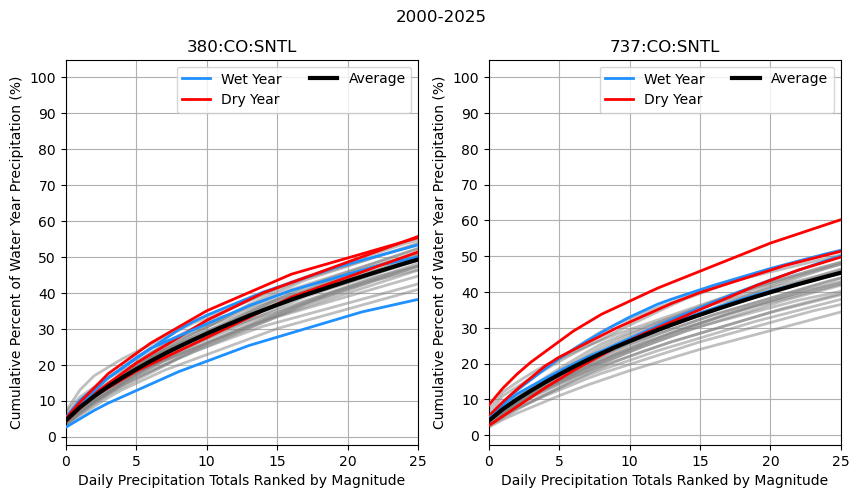

In [16]:
fig, axs = plt.subplots(ncols=2, figsize=(10,5))

ranked_years_list = []
for i,site in enumerate(sntl_df.site.unique()):
    df = sntl_df[sntl_df['site']==site]
    ranked_years = df.groupby('WY').sum('PRECIPITATION').sort_values('PRECIPITATION', ascending=False)
    ranked_years_list.append(ranked_years)
    norm_list = []
    dry_label='Dry Year'
    wet_label='Wet Year'
    for wy in sntl_df['WY'].unique():
        wy_df = df[df['WY']==wy].sort_values('PRECIPITATION', ascending=False)['PRECIPITATION']
        # normalize by total PRECIPITATION
        wy_df_norm = wy_df/wy_df.sum() * 100
        wy_df_norm.reset_index(drop=True, inplace=True)
        wy_df_norm.name = wy
        norm_list.append(wy_df_norm)

        if wy in ranked_years.iloc[0:3].index:
            wy_df_norm.cumsum().plot(ax=axs[i], lw=2, color='dodgerblue',label=wet_label, zorder=100)
            wet_label="_"
        elif wy in ranked_years.iloc[-3:].index:
            wy_df_norm.cumsum().plot(ax=axs[i], lw=2, color='red', label=dry_label, zorder=100)
            dry_label="_"
        else:
            wy_df_norm.cumsum().plot(ax=axs[i], lw=2, alpha=0.5, color='grey', label='_')
        
    # plot average water year
    avg_norm_df = pd.concat(norm_list, axis=1).mean(axis=1)
    avg_norm_df.cumsum().plot(ax=axs[i], lw=3, ls='-', label="Average", color='k',zorder=101)

    axs[i].set_xlim(0,25)
    axs[i].set_yticks(range(0,110,10))
    axs[i].set_title(site)
    axs[i].set_ylabel("Cumulative Percent of Water Year Precipitation (%)")
    axs[i].set_xlabel("Daily Precipitation Totals Ranked by Magnitude")
    axs[i].legend(ncol=2)
    axs[i].grid()
    fig.suptitle('2000-2025')